# Introduction to Convolutional Neural Networks

Convolutional Neural Networks (CNNs), are neural network architectures inspired by the human visual system, designed to process image data by capturing spatial relationships between pixels.

- Learn hierarchical features from simple edges to complex objects
- Capture spatial patterns using convolution operations
- Detect objects regardless of their position in the image
- Reduce computation by focusing on local regions instead of the entire image

![General Architecture of CNN](1-the-general-architecture.webp)

## <br>Key Components of CNN

A complete CNN architecture is also known as a **ConvNet** — a sequence of layers where every layer transforms one volume to another through a differentiable function. Example input: image of dimension **32 × 32 × 3**.

### 1. Input Layer
Receives raw image data as a 3D volume (width × height × depth).
- Stores pixel values (e.g., 32 × 32 × 3 for RGB)
- Preserves spatial structure for feature extraction

### 2. Convolutional Layer
Applies learnable filters (kernels) that slide over the image, computing dot products to produce feature maps.
- Uses small filters (e.g., 2×2, 3×3, 5×5)
- Captures patterns like edges, textures, and shapes
- Example: 12 filters → output volume **32 × 32 × 12**

### 3. Activation Layer
Applies an element-wise non-linearity to enable the model to learn complex patterns.
- Common functions: ReLU, Tanh, Leaky ReLU
- Output dimensions unchanged (e.g., 32 × 32 × 12)

### 4. Pooling Layer
Reduces spatial dimensions to lower computation, memory usage, and overfitting risk.
- Types: Max Pooling, Average Pooling
- Reduces width & height, depth unchanged
- Example: 2×2 max pool, stride 2 → **32 × 32 × 12** → **16 × 16 × 12**

![Max Pooling](2-max-pooling.webp)

### 5. Flattening
Converts multi-dimensional feature maps into a 1D vector to feed into the fully connected layer.
- Example: **16 × 16 × 12** → vector of size **3072**

### 6. Fully Connected Layer
Performs high-level reasoning on extracted features to produce final classification scores.
- Example: 3072-length vector connected to output neurons for classification

### 7. Output Layer
Converts final scores into probabilities using an activation function.
- **Sigmoid** — binary classification
- **Softmax** — multi-class classification
- Example: 10 classes → Softmax outputs **10 probability values**

## <br>How Convolutional Layers Work

A small matrix called a **filter (kernel)** slides over the input image to extract features:

- At each position, the filter performs element-wise multiplication with the image patch, then sums the results into a single output value
- Repeated across the entire image using a defined **stride**
- Produces a **feature map** that highlights detected patterns
- Multiple filters capture different features — edges, textures, shapes
- Preserves spatial relationships while reducing learnable parameters vs. fully connected layers
- **Padding** controls output size and prevents loss of border information

![How Convolution Layers Work](3-concolution-layers-work.webp)

## <br>Step By Step Implementation

Here we implement a Convolutional Neural Network illustrating how each layer processes and transforms the input image.

### Step 1: Import Required Libraries
Import PyTorch for CNN operations and Matplotlib for visualization.

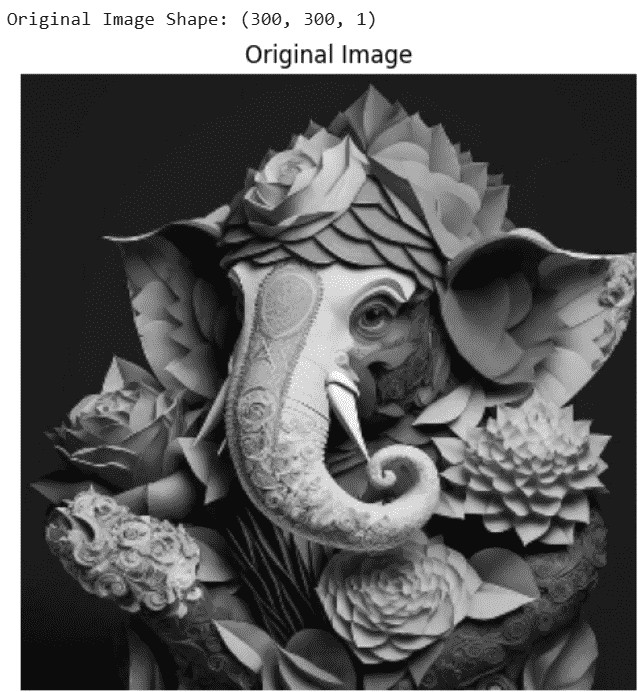

In [5]:
import torch
import torchvision.transforms as transforms  # tools to preprocess images (resize, normalize, convert)
from PIL import Image           # Python Imaging Library — opens and manipulates image files
import matplotlib.pyplot as plt

plt.rc('image', cmap='gray')       # rc = runtime configuration; sets default colormap to grayscale for all images
plt.rc('figure', autolayout=True)  # 'figure' = global figure settings; autolayout=True auto-adjusts spacing so titles/labels don't overlap

image_path = "elephant.png"
image = Image.open(image_path).convert('L')  # 'L' = grayscale (1 channel instead of 3)

image

In [6]:
transform = transforms.Compose([
    transforms.Resize((300, 300)),  # rescale image to fixed 300×300 pixels
    transforms.ToTensor(),          # converts PIL image to → PyTorch tensor and scales pixels to [0.0, 1.0]
])

image = transform(image)
image

tensor([[[1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         ...,
         [1.0000, 1.0000, 1.0000,  ..., 0.1098, 0.1412, 0.6275],
         [1.0000, 1.0000, 1.0000,  ..., 0.1490, 0.1804, 0.6431],
         [1.0000, 1.0000, 1.0000,  ..., 0.6902, 0.7020, 0.8745]]])

Original Image Shape:  torch.Size([1, 300, 300])


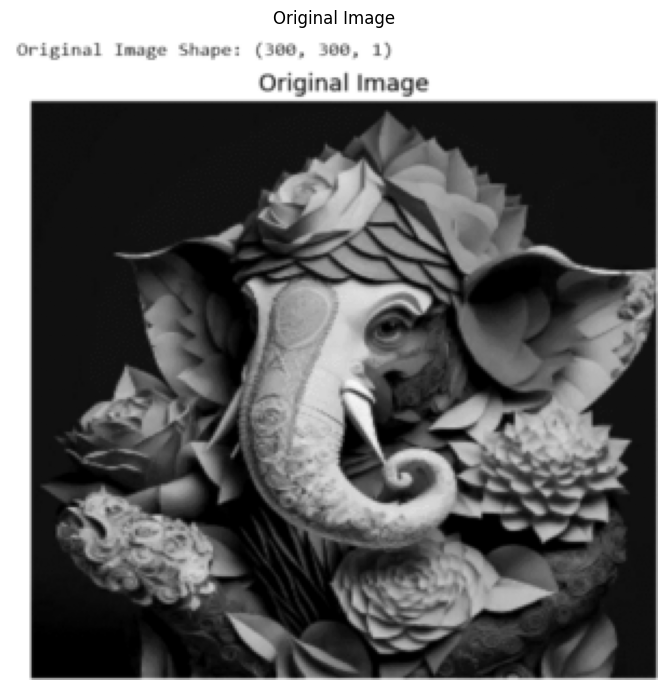

Image with batch dimension: torch.Size([1, 1, 300, 300])


In [7]:
print("Original Image Shape: ", image.shape)   # (1, 300, 300) → channels, height, width

plt.figure(figsize=(7,7))

# squeeze() removes the channel dim (1,300,300) → (300,300) so plt can display it
# cmap='gray' renders pixel values as shades of gray (0=black, 1=white)
plt.imshow(image.squeeze(), cmap='gray') 

plt.title("Original Image")
plt.axis('off')
plt.show()

# CNNs expect input as (batch, channels, height, width)
# unsqueeze(0) adds the batch dim: (1, 300, 300) → (1, 1, 300, 300)
image = image.unsqueeze(0)
print("Image with batch dimension:", image.shape)

### Step 3: Define Convolution Kernel

A **kernel** (or filter) is a small matrix of weights that slides over the image to detect patterns.
Here we use the **Laplacian kernel** — a classic edge detection filter that emphasizes regions
where pixel intensity changes sharply (edges, borders, outlines).

```
-1  -1  -1
-1   8  -1
-1  -1  -1
```

The center pixel gets multiplied by 8 while all 8 surrounding neighbors are subtracted.
If all pixels in a region are similar (flat area), the result cancels out to ~0.
If the center differs from its neighbors (an edge), the result is a large value — the edge is detected.

PyTorch requires the kernel to be shaped as **(out_channels, in_channels, height, width)**:
- `out_channels = 1` — we apply 1 filter, producing 1 feature map
- `in_channels = 1` — our image is grayscale (1 channel)
- `3, 3` — the filter covers a 3×3 pixel region at each step

### Step 4: Apply Convolution Layer

`F.conv2d` slides the kernel across every position of the image and computes the dot product
between the kernel weights and the pixel values underneath it, producing a **feature map**.

**Input shape:** `(1, 1, 300, 300)` → (batch, channels, height, width)

| Dimension | Value | Meaning |
|-----------|-------|---------|
| batch | 1 | processing 1 image at a time |
| channels | 1 | grayscale image (RGB would be 3) |
| height | 300 | 300 pixels tall |
| width | 300 | 300 pixels wide |

**Padding = 1** adds a border of zeros around the image before the filter is applied:
- Without padding, a 3×3 filter on a 300×300 image shrinks the output to 298×298
  because the filter cannot center itself on border pixels
- `padding=1` preserves the original size → output remains **300×300**
- General rule: `padding = (kernel_size − 1) / 2` → `(3−1)/2 = 1`

**Output shape:** `(1, 1, 300, 300)` — same spatial size, now containing edge intensities instead of raw pixel values. Bright regions in the output correspond to detected edges.

Pure Tensor: tensor([[-1., -1., -1.],
        [-1.,  8., -1.],
        [-1., -1., -1.]])
Reshaped Tensor: tensor([[[[-1., -1., -1.],
          [-1.,  8., -1.],
          [-1., -1., -1.]]]])
After Convolution Shape: torch.Size([1, 1, 300, 300])


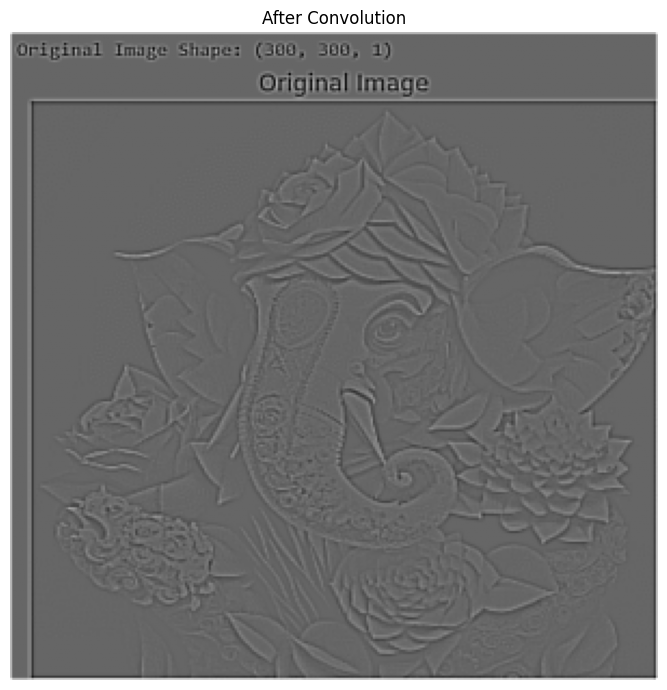

In [8]:
import torch.nn.functional as F   # functional API — stateless math operations (conv, relu, pooling) called as plain functions

# Laplacian kernel — edge detection filter: highlights areas of rapid intensity change
kernel = torch.tensor([
    [-1., -1., -1.],
    [-1.,  8., -1.],
    [-1., -1., -1.]
])

print("Pure Tensor:", kernel)
kernel = kernel.reshape(1, 1, 3, 3)
print("Reshaped Tensor:", kernel)

conv_output = F.conv2d(
    input=image,
    weight=kernel,
    padding=1
)

print("After Convolution Shape:", conv_output.shape)

plt.figure(figsize=(7, 7))
plt.imshow(conv_output.squeeze().detach())
plt.title("After Convolution")
plt.axis('off')
plt.show()

### <br>Appling ReLU Activation Function

After ReLU Shape: torch.Size([1, 1, 300, 300])


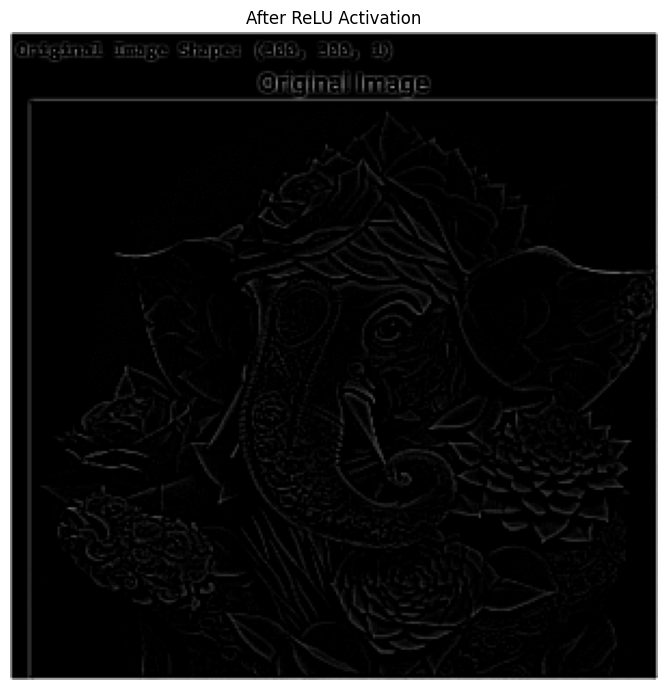

In [9]:
relu_output = F.relu(conv_output)   # sets all negative values to 0, keeps positive values unchanged

print("After ReLU Shape:", relu_output.shape)

plt.figure(figsize=(7, 7))
plt.imshow(relu_output.squeeze().detach())
plt.title("After ReLU Activation")
plt.axis('off')
plt.show()

### <br>Appling Max Pooling Layer

After Pooling Shape: torch.Size([1, 1, 150, 150])


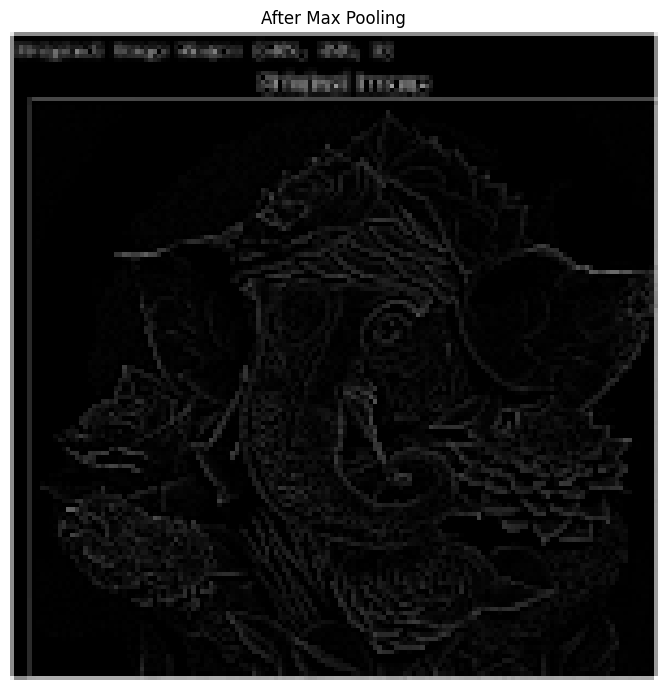

In [10]:
pool_output = F.max_pool2d(relu_output, kernel_size=2, stride=2)

print("After Pooling Shape:", pool_output.shape)

plt.figure(figsize=(7, 7))
plt.imshow(pool_output.squeeze().detach())
plt.title("After Max Pooling")
plt.axis('off')
plt.show()

### <br>Apply Flatten Layer

The flatten layer converts the 2D feature maps into a **1D feature vector** so it can be passed into a fully connected layer.

- `torch.flatten(input, start_dim=1)` collapses all dimensions from `start_dim` onward into one
- `start_dim=1` keeps the batch dimension intact and flattens only channels × height × width
- Example: `(1, 1, 150, 150)` → `(1, 22500)` — 1 sample, 22500 features

In [11]:
flatten_output = torch.flatten(pool_output, start_dim=1)  # (1, 1, 150, 150) → (1, 22500)

print("After Flatten Shape:", flatten_output.shape)
print("First 20 Flattened Values:")
print(flatten_output.numpy()[0][:20])

After Flatten Shape: torch.Size([1, 22500])
First 20 Flattened Values:
[5. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3.]


### <br>Add Fully Connected (Dense) Layer

`nn.Linear` is PyTorch's equivalent of TensorFlow's `Dense` layer. It connects every input feature to every output neuron and learns high-level patterns for classification.

- `in_features` — size of the flattened vector (e.g. 22500), inferred dynamically from the tensor
- `out_features=64` — number of neurons in this layer; each learns a different combination of features
- ReLU is applied separately via `F.relu()` since `nn.Linear` has no built-in activation parameter

In [12]:
import torch.nn as nn

in_features = flatten_output.shape[1]  # dynamically reads the flattened size (e.g. 22500)
dense_layer = nn.Linear(in_features=in_features, out_features=64)
dense_output = F.relu(dense_layer(flatten_output))

print("After Fully Connected Layer Shape:", dense_output.shape)

After Fully Connected Layer Shape: torch.Size([1, 64])


## <br>Advantages & Limitations

**Advantages**
- Automatically learns important features from images, videos, or audio without manual extraction
- Highly effective at detecting spatial patterns, edges, textures, and shapes
- Robust to variations like translation, rotation, and scaling in input data
- Handles large datasets and achieves high predictive accuracy
- Supports end-to-end training, simplifying the model pipeline

**Limitations**
- Training is computationally intensive and requires significant memory
- Prone to overfitting when data is limited or regularization is insufficient
- Requires large amounts of labeled data for optimal performance
- Limited interpretability — difficult to understand what features the model has learned
- Sensitive to adversarial examples and noise in input data